In [1]:
import h5py, numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

path = '/data/tommylub/h5_files/nom_ttbb_10jets_b1b2_train.h5'

# important physical variables were interested in sampling
V = ['ttbar_m','ttbar_pt','th_pt','tl_pt','th_m','tl_m']

In [2]:
f = h5py.File(path, 'r')
print(f.keys())

<KeysViewHDF5 ['b1_eta', 'b1_m', 'b1_phi', 'b1_pt', 'b2_eta', 'b2_m', 'b2_phi', 'b2_pt', 'j10_eta', 'j10_isExtraB', 'j10_isFromttbar', 'j10_isTruth', 'j10_isbtag', 'j10_m', 'j10_phi', 'j10_pt', 'j1_eta', 'j1_isExtraB', 'j1_isFromttbar', 'j1_isTruth', 'j1_isbtag', 'j1_m', 'j1_phi', 'j1_pt', 'j2_eta', 'j2_isExtraB', 'j2_isFromttbar', 'j2_isTruth', 'j2_isbtag', 'j2_m', 'j2_phi', 'j2_pt', 'j3_eta', 'j3_isExtraB', 'j3_isFromttbar', 'j3_isTruth', 'j3_isbtag', 'j3_m', 'j3_phi', 'j3_pt', 'j4_eta', 'j4_isExtraB', 'j4_isFromttbar', 'j4_isTruth', 'j4_isbtag', 'j4_m', 'j4_phi', 'j4_pt', 'j5_eta', 'j5_isExtraB', 'j5_isFromttbar', 'j5_isTruth', 'j5_isbtag', 'j5_m', 'j5_phi', 'j5_pt', 'j6_eta', 'j6_isExtraB', 'j6_isFromttbar', 'j6_isTruth', 'j6_isbtag', 'j6_m', 'j6_phi', 'j6_pt', 'j7_eta', 'j7_isExtraB', 'j7_isFromttbar', 'j7_isTruth', 'j7_isbtag', 'j7_m', 'j7_phi', 'j7_pt', 'j8_eta', 'j8_isExtraB', 'j8_isFromttbar', 'j8_isTruth', 'j8_isbtag', 'j8_m', 'j8_phi', 'j8_pt', 'j9_eta', 'j9_isExtraB', 'j9_i

In [3]:
print(f['ttbar_m'][0:500])

[ 534362.6875   608000.375    770053.125    537335.125    611604.0625
  727534.3125   833851.4375   548388.0625   433708.125    434080.5
  465972.625    481352.       443591.8125   761307.125    670514.125
  384337.25     945060.9375   433780.21875  418100.46875  465911.15625
  490236.34375  452633.09375  503675.5      534962.875    890376.0625
  463575.375    376408.9375   784115.1875   401266.28125  440470.28125
  680689.0625   429280.25     366884.1875   742766.8125   412995.4375
  367425.65625  622145.3125   499426.0625  1264908.25     446150.90625
  363248.28125  536316.4375   573193.25     947712.4375   583926.
  390264.96875  691940.5625   591600.8125   560558.625    440346.5625
  478587.40625  536553.6875   808166.0625   647162.       451184.03125
  379031.71875  591485.375    450065.28125  667451.1875   557051.875
  478551.09375  716573.0625   522350.15625  339984.5      433336.8125
  440507.25     481946.6875   528388.       449988.09375  381133.34375
  510625.6875   524349.2

(array([7.106e+03, 2.174e+03, 5.140e+02, 1.500e+02, 4.100e+01, 9.000e+00,
        4.000e+00, 0.000e+00, 0.000e+00, 2.000e+00]),
 array([ 336143.625 ,  597106.0875,  858068.55  , 1119031.0125,
        1379993.475 , 1640955.9375, 1901918.4   , 2162880.8625,
        2423843.325 , 2684805.7875, 2945768.25  ]),
 <BarContainer object of 10 artists>)

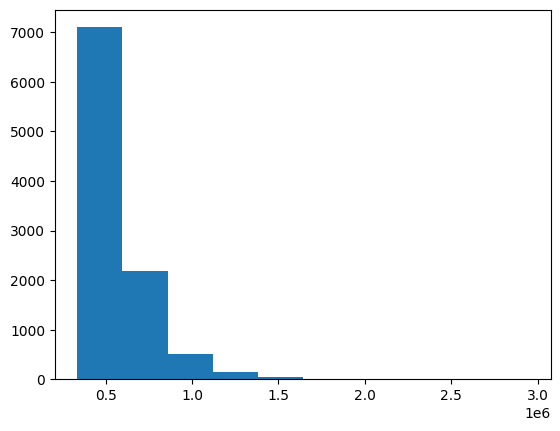

In [4]:
plt.hist(f['ttbar_m'][0:10000])

In [5]:
def read_arrays(f, key):
    return f[key][:]


# peek at the ranges and quantiles
Q = {}
for v in V:
    a = read_arrays(f, v)
    Q[v] = np.quantile(a, [0.5, 0.8, 0.9, 0.95, 0.99, 0.999])
    print(f'{v:9s} | min={a.min():.3f}  median={Q[v][0]:.3f}  0.95={Q[v][3]:.3f}  0.99={Q[v][4]:.3f}')



ttbar_m   | min=323989.656  median=503914.500  0.95=926304.962  0.99=1256566.455
ttbar_pt  | min=26.459  median=101527.828  0.95=344069.306  0.99=530238.082
th_pt     | min=61.427  median=144693.188  0.95=359527.594  0.99=502303.430
tl_pt     | min=128.481  median=149449.969  0.95=366173.637  0.99=507451.996
th_m      | min=159210.312  median=172486.688  0.95=175662.203  0.99=180606.801
tl_m      | min=159210.016  median=172488.062  0.95=175676.547  0.99=180672.356


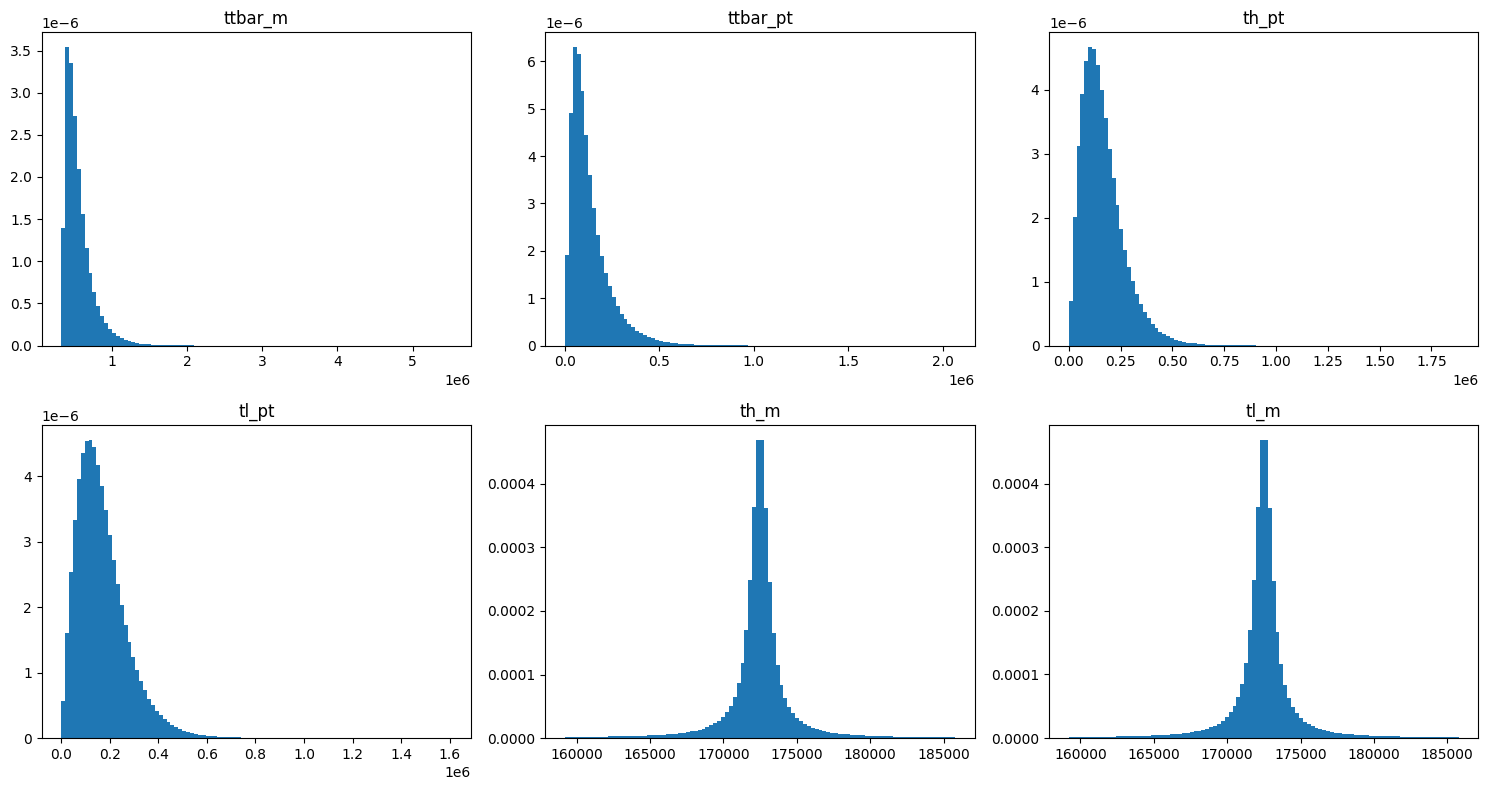

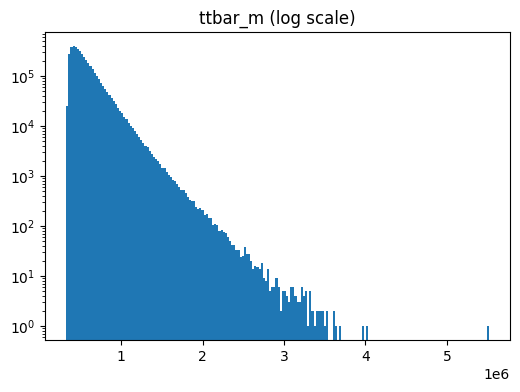

In [6]:
# quick hist overlays

fig, axs = plt.subplots(2, 3, figsize=(15,8))

axs = axs.ravel()

for i, v in enumerate(V):
    axs[i].hist(read_arrays(f, v), bins=100, density=True)
    axs[i].set_title(v)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6,4))
x = read_arrays(f, 'ttbar_m')
plt.hist(x, bins=200, log=True)
plt.title("ttbar_m (log scale)")
plt.show()


['reco;1', 'reco_scaled;1', 'parton;1', 'parton_scaled;1']
['th_pt', 'th_eta', 'th_phi', 'th_m', 'wh_pt', 'wh_eta', 'wh_phi', 'wh_m', 'tl_pt', 'tl_eta', 'tl_phi', 'tl_m', 'wl_pt', 'wl_eta', 'wl_phi', 'wl_m', 'ttbar_pt', 'ttbar_eta', 'ttbar_phi', 'ttbar_m', 'b1_pt', 'b1_eta', 'b1_phi', 'b1_m', 'b2_pt', 'b2_eta', 'b2_phi', 'b2_m']


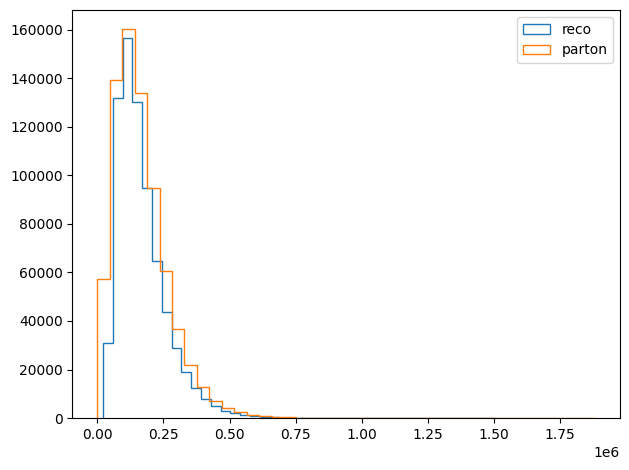

In [22]:
import uproot

with uproot.open('/home/tommylub/TRecNet/trained_models/TRecNet_ttbb_v5x1_clf/TRecNet_ttbb_v5x1_clf_b1b2+ttbar/TRecNet_ttbb_v5x1_clf_b1b2+ttbar_10jets_20251019_213359/results/Results.root') as f:
    print(f.keys())  # expect: ['reco;1', 'reco_scaled;1', 'parton;1', 'parton_scaled;1']
    print(f['reco'].keys())  # branch names match your dict keys

    arr1 = np.asarray(f['reco']['th_pt'])
    arr2 = np.asarray(f['parton']['th_pt'])

plt.hist(arr1, bins=40, histtype='step', label = 'reco')
plt.hist(arr2, bins=40, histtype='step', label = 'parton')
plt.legend()
plt.tight_layout()
plt.show()
